In [1]:
import numpy as np
import matplotlib.pyplot as plt
import general_functions
from scipy.linalg import expm
import time as tm

In [2]:
N=20
k=3

t1=tm.time()

In [3]:
def vecU(t):
    a=[0.07747897282755545, -0.563632017585953, 0.47017428975720826, -0.2745107053189222, 0.13071778117587068]
    U1=a[0] + a[1]*t + a[2]*t**2 + a[3]*t**4 + a[4]*t**5 
    return np.array([U1, U1, U1])

In [4]:
def J(t):
    return (1.0 + 0.0*np.sin(0.5*t))

In [5]:
def Delta(t):
    b = [1.0471264153979678, 0.39289819529909775, -0.0758928824380212, -0.08082406801993186, -0.41591786297140004]
    return (b[0] + b[1]*t + b[2]*t**2 + b[3]*t**4 + b[4]*t**5)

In [6]:
def tevol(N, k, psi0, T, num_steps, J, vecU, Delta):
    tspan=np.linspace(0, T, num_steps)
    M=general_functions.common_matrices(N, k)
    Interaction=M["Interaction"]
    Sz=M["Sz"]
    Szd=np.diag(Sz)
    Hopping=M["Hopping"]
    dt=tspan[1]-tspan[0]
    
    psi_list=[]
    FI=[]
    psi=psi0
        
    for j in range(num_steps):
        psi_list.append(psi)
        FI.append(general_functions.fisher_info_pure(psi, Sz))
        psi=np.exp(-1j*dt*np.dot(vecU(tspan[j]), Interaction))*psi
        psi=np.exp(-1j*dt*Delta(tspan[j])*Szd)*psi
        psi=np.dot(expm(-1j*dt*J(tspan[j])*Hopping), psi)
        #print(np.sum(np.abs(psi)**2))
        
    
    return tspan, FI, psi_list

In [7]:
S=general_functions.common_states(N, k)
psi0 = np.zeros(231)
psi0[0] = 1

T=2
num_steps=201
tspan, FI, psi_list=tevol(N, k, psi0, T, num_steps, J, vecU, Delta)

/var/folders/lt/ss6345jj48qc3jwrvtn9d7y00000gn/T/ipykernel_55852/3550505460.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


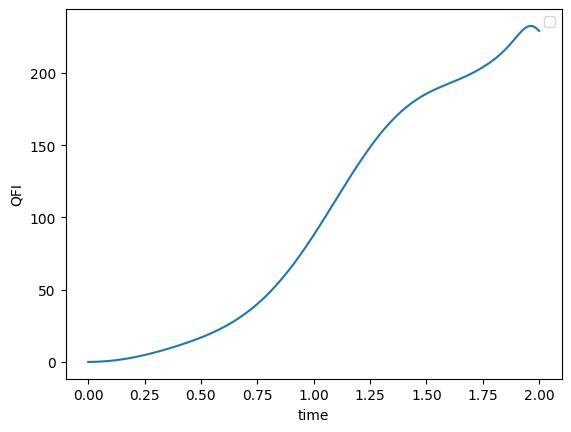

In [9]:
plt.figure()
plt.xlabel("time")
plt.ylabel("QFI")
plt.plot(tspan, np.array(FI))
plt.legend()